<a href="https://colab.research.google.com/github/JamesSembukuttiarachchi/rain_in_australia/blob/feat%2Fusing-random-forest/03_random_forest_weatherAUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier

DATA_PATH = "/content/drive/MyDrive/weatherAUS_balanced.csv"   # keep the CSV in the same folder as this notebook, or update this path

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (220632, 23)
Columns: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0.0,0.0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0.0,0.0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0.0,0.0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0.0,0.0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0.0,0.0


After mounting Google Drive, ensure you upload `weatherAUS.csv` to your Drive (e.g., in the root 'MyDrive' folder or a specific subfolder). Then, update the `DATA_PATH` variable below to point to its correct location in your Google Drive.

In [3]:
# =========================
# 1. CLEAN TARGET FIRST (SAFE VERSION)
# =========================

print("Before cleaning:", df.shape)
print("Target unique values:", df["RainTomorrow"].unique())

# Case 1: Already numeric (0/1)
if df["RainTomorrow"].dtype != "object":
    df = df.dropna(subset=["RainTomorrow"])
    df["RainTomorrow"] = df["RainTomorrow"].astype(int)

# Case 2: String values (Yes/No)
else:
    df["RainTomorrow"] = df["RainTomorrow"].astype(str).str.strip()
    df = df[df["RainTomorrow"].isin(["Yes", "No"])]
    df["RainTomorrow"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})

print("After cleaning:", df.shape)


# =========================
# 2. CLEAN RainToday (SAFE)
# =========================

if df["RainToday"].dtype == "object":
    df["RainToday"] = df["RainToday"].astype(str).str.strip()
    df["RainToday"] = df["RainToday"].map({"No": 0, "Yes": 1})


# =========================
# 3. DATE FEATURE ENGINEERING
# =========================

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfYear"] = df["Date"].dt.dayofyear

df = df.drop(columns=["Date"])

Before cleaning: (220632, 23)
Target unique values: [0. 1.]
After cleaning: (220632, 23)


In [4]:
# =========================
# 4. HANDLE MISSING VALUES
# =========================

# Numerical → median
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


# Categorical → safe mode / drop high-missing
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    missing_ratio = df[col].isna().mean()

    if missing_ratio > 0.6:
        # Drop columns with too many missing values
        print(f"Dropping column (too many NaNs): {col}")
        df = df.drop(columns=[col])
    else:
        mode_val = df[col].mode()
        if mode_val.empty:
            df[col] = df[col].fillna("Unknown")
        else:
            df[col] = df[col].fillna(mode_val[0])


# =========================
# 5. ENCODE CATEGORICAL
# =========================

# Recalculate categorical columns after dropping
cat_cols = df.select_dtypes(include=["object"]).columns

from sklearn.preprocessing import LabelEncoder

le_dict = {}  # store encoders

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le


# =========================
# 6. FINAL SAFETY CHECK
# =========================

print("\n===== SAFETY CHECK =====")
print("NaN in target:", df["RainTomorrow"].isna().sum())
print("NaN in features:", df.drop("RainTomorrow", axis=1).isna().sum().sum())

# Optional debug
if df.drop("RainTomorrow", axis=1).isna().sum().sum() > 0:
    print("⚠️ Still NaNs present — check columns:")
    print(df.isna().sum()[df.isna().sum() > 0])


# =========================
# 7. SPLIT DATA
# =========================

from sklearn.model_selection import train_test_split

X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"]

# Final check before split
assert y.isna().sum() == 0, "❌ Target still has NaNs!"
assert X.isna().sum().sum() == 0, "❌ Features still have NaNs!"

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===== DATA SPLIT =====")
print("Train:", X_train.shape)
print("Test:", X_test.shape)


===== SAFETY CHECK =====
NaN in target: 0
NaN in features: 0

===== DATA SPLIT =====
Train: (176505, 25)
Test: (44127, 25)


## Train Random Forest

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=15, n_estimators=200, n_jobs=-1,
                       random_state=42)

## Evaluate the model

===== BASIC METRICS =====
Accuracy  : 0.8882
Precision : 0.8724
Recall    : 0.9094
F1 Score  : 0.8905

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.91      0.87      0.89     22064
           1       0.87      0.91      0.89     22063

    accuracy                           0.89     44127
   macro avg       0.89      0.89      0.89     44127
weighted avg       0.89      0.89      0.89     44127


===== CONFUSION MATRIX =====
[[19130  2934]
 [ 2000 20063]]


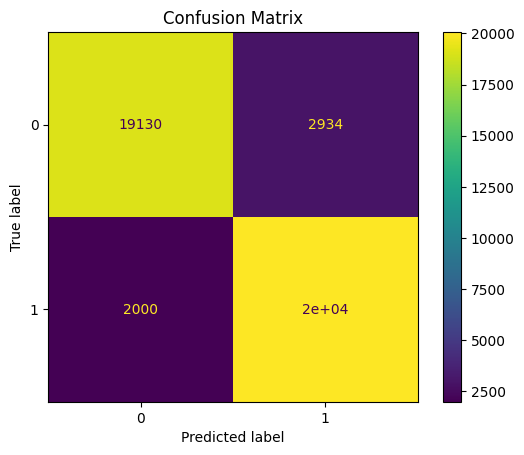

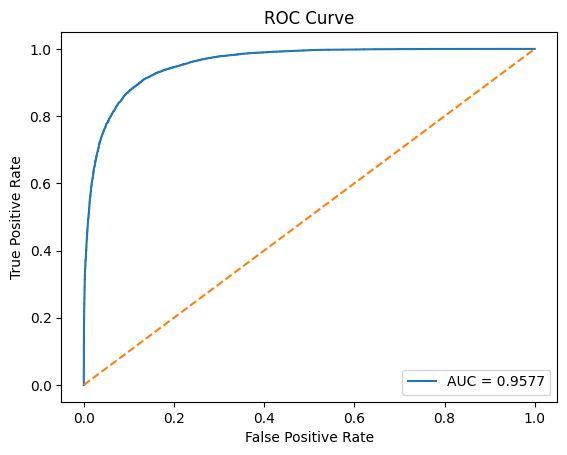


AUC Score: 0.9577

===== CROSS VALIDATION =====
Scores: [0.78523353 0.79717633 0.82937497 0.75214159 0.8317092 ]
Mean CV Score: 0.7991

===== OVERFITTING CHECK =====
Training Accuracy: 0.9311
Testing Accuracy : 0.8882

===== FINAL SUMMARY =====
      Metric     Score
0   Accuracy  0.888186
1  Precision  0.872418
2     Recall  0.909350
3   F1 Score  0.890502
4        AUC  0.957711
5    CV Mean  0.799127


In [6]:
# ---- Predictions ----
y_pred = rf.predict(X_test)
y_probs = rf.predict_proba(X_test)[:, 1]


# ---- Basic Metrics ----
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== BASIC METRICS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# ---- Confusion Matrix ----
print("\n===== CONFUSION MATRIX =====")
cm = confusion_matrix(y_test, y_pred)
print(cm)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()


# ---- ROC Curve + AUC ----
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("\nAUC Score:", round(roc_auc, 4))


# ---- Cross Validation ----
cv_scores = cross_val_score(rf, X, y, cv=5)

print("\n===== CROSS VALIDATION =====")
print("Scores:", cv_scores)
print("Mean CV Score:", round(cv_scores.mean(), 4))


# ---- Overfitting Check ----
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print("\n===== OVERFITTING CHECK =====")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy : {test_acc:.4f}")


# ---- Summary Table ----
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC", "CV Mean"],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        cv_scores.mean()
    ]
})

print("\n===== FINAL SUMMARY =====")
print(results)

## Model-specific interpretation

          Feature  Importance
13    Humidity3pm    0.216392
5        Sunshine    0.078928
3        Rainfall    0.065311
15    Pressure3pm    0.061088
7   WindGustSpeed    0.056489
12    Humidity9am    0.051239
17       Cloud3pm    0.049194
14    Pressure9am    0.049019
20      RainToday    0.043407
19        Temp3pm    0.032799


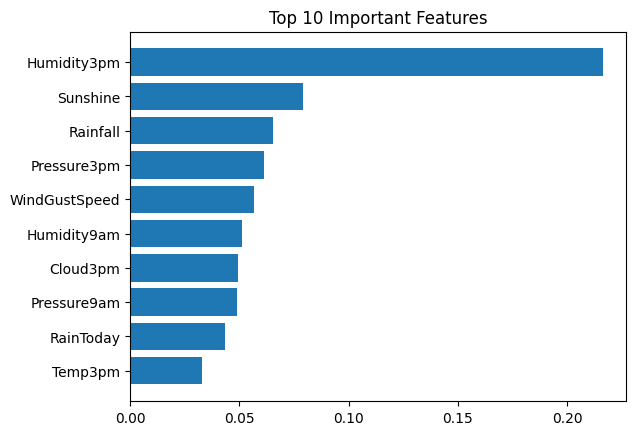

In [7]:
importances = rf.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

# Plot
plt.figure()
plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()


In [8]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

best_rf = grid.best_estimator_

Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
